# Actividad Práctica Final: Visualización de Grandes Volúmenes de Datos con Apache Spark

| Campo | Detalle |
|---|---|
| **Asignatura** | Herramientas y Visualización de Datos |
| **Estudiante** | Jhon Alexander Vargas Catuche |
| **Dataset** | NYC Yellow Taxi Trip Records |
| **Fuente** | NYC Taxi & Limousine Commission (TLC) |
| **Enlace de descarga** | https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| **Período analizado** | 2023 – 2024 |
| **Fecha de entrega** | 4 de junio de 2026 |

---


## 1. Introducción

Este notebook desarrolla la actividad final de visualización de grandes volúmenes de datos utilizando **Apache Spark**.
El dataset seleccionado contiene los registros de viajes de taxis amarillos de la ciudad de Nueva York, publicados mensualmente por la **NYC Taxi & Limousine Commission (TLC)**.

### Fuente y enlace de descarga

- **Fuente oficial:** NYC Taxi & Limousine Commission (TLC) — *TLC Trip Record Data*.
- **Página oficial:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
- **Enlace directo de descarga (archivos Parquet mensuales):** `https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{año}-{mes}.parquet`
- En este trabajo se descargan los meses de **2023 y 2024 completos** (ver sección 4), superando 1 GB de datos.

### Variables disponibles en el dataset

| Variable | Descripción |
|---|---|
| `tpep_pickup_datetime` | Fecha y hora de inicio del viaje |
| `tpep_dropoff_datetime` | Fecha y hora de finalización del viaje |
| `trip_distance` | Distancia recorrida (millas) |
| `passenger_count` | Cantidad de pasajeros |
| `PULocationID / DOLocationID` | Zona de recogida y destino |
| `payment_type` | Tipo de pago (tarjeta, efectivo, etc.) |
| `fare_amount` | Tarifa base |
| `tip_amount` | Propina |
| `tolls_amount` | Peajes |
| `total_amount` | Valor total pagado |

### Justificación del dataset

Se eligió este dataset porque:
- Supera **1 GB** al utilizar múltiples meses, cumpliendo el requisito del taller.
- Combina variables **numéricas, categóricas y temporales**, permitiendo análisis multidimensionales.
- Es de dominio público, con fuente oficial y reproducible.
- Permite responder preguntas relevantes sobre movilidad urbana, comportamiento de usuarios y patrones de demanda.

### Preguntas de análisis

1. ¿Cómo evoluciona la cantidad de viajes por mes a lo largo de 2023 y 2024?
2. ¿Cuáles son los medios de pago más utilizados por los usuarios?
3. ¿Qué relación existe entre la distancia del viaje y el valor total pagado?
4. ¿En qué días de la semana y horas del día se concentra la mayor demanda?
5. ¿Cómo se distribuyen los valores pagados por los usuarios?


## 2. Instalación y Configuración del Entorno

Ejecuta la siguiente celda **solo si las librerías no están instaladas** en tu entorno.

> **Nota para Windows:** Spark requiere Java (JDK 8 o 11). Descárgalo desde [adoptium.net](https://adoptium.net/) e instálalo antes de continuar.


In [ ]:
# Descomenta y ejecuta si hace falta instalar dependencias
# !pip install pyspark pandas matplotlib seaborn plotly

## 3. Importación de Librerías y Configuración Global

Se importan todas las librerías necesarias y se establece un tema visual coherente para todas las gráficas del proyecto.


In [1]:
import os
import sys
import warnings
import urllib.request
from pathlib import Path
from functools import reduce

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Silenciar advertencias menores que no afectan la ejecución
warnings.filterwarnings('ignore')

# ── Rutas del proyecto ──────────────────────────────────────────────────
# Path.cwd() garantiza rutas correctas tanto en Jupyter como en VS Code.
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR    = PROJECT_DIR / 'data'
OUTPUT_DIR  = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Variables de entorno para PySpark ───────────────────────────────────
os.environ.setdefault('PYSPARK_PYTHON', sys.executable)
os.environ.setdefault('PYSPARK_DRIVER_PYTHON', sys.executable)

# Configuración adicional necesaria en Windows
if sys.platform.startswith('win'):
    import tempfile
    hadoop_home = Path(tempfile.gettempdir()) / 'hadoop'
    (hadoop_home / 'bin').mkdir(parents=True, exist_ok=True)
    os.environ.setdefault('HADOOP_HOME', str(hadoop_home))
    os.environ.setdefault('hadoop.home.dir', str(hadoop_home))

    # winutils.exe es requerido por Spark/Hadoop en Windows para acceder
    # al sistema de archivos local. Sin él, spark.read.parquet() falla
    # con un Py4JJavaError al intentar ejecutar el primer job.
    winutils_path = hadoop_home / 'bin' / 'winutils.exe'
    if not winutils_path.exists():
        winutils_url = (
            'https://github.com/cdarlint/winutils/raw/master/'
            'hadoop-3.3.5/bin/winutils.exe'
        )
        try:
            print('Descargando winutils.exe para Windows...', end=' ')
            urllib.request.urlretrieve(winutils_url, winutils_path)
            print(f'OK  →  {winutils_path}')
        except Exception as e:
            print(f'ADVERTENCIA: No se pudo descargar winutils.exe — {e}')
            print('Descárgalo manualmente desde https://github.com/cdarlint/winutils')
            print(f'y colócalo en: {winutils_path}')
    else:
        print(f'winutils.exe ya presente en {winutils_path}')

# ── Tema visual global para todas las gráficas ──────────────────────────
PALETTE       = 'viridis'
ACCENT_COLOR  = '#1f77b4'
FIG_DPI       = 160

sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.figsize':    (13, 6),
    'figure.dpi':        FIG_DPI,
    'axes.titlesize':    15,
    'axes.titleweight':  'bold',
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'savefig.dpi':       FIG_DPI,
    'savefig.bbox':      'tight',
})

print(f'Carpeta del proyecto : {PROJECT_DIR}')
print(f'Carpeta de datos     : {DATA_DIR}')
print(f'Carpeta de salidas   : {OUTPUT_DIR}')
print('Entorno configurado correctamente.')


winutils.exe ya presente en C:\Users\JHONVA~1\AppData\Local\Temp\hadoop\bin\winutils.exe
Carpeta del proyecto : C:\Users\JHON VARGAS\Downloads\Vargas_Catuche_hvd_spark_taller_final\hvd_spark_final
Carpeta de datos     : C:\Users\JHON VARGAS\Downloads\Vargas_Catuche_hvd_spark_taller_final\hvd_spark_final\data
Carpeta de salidas   : C:\Users\JHON VARGAS\Downloads\Vargas_Catuche_hvd_spark_taller_final\hvd_spark_final\outputs
Entorno configurado correctamente.


In [2]:
# ── Configuración visual profesional (dark theme) ──────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

DARK_BG    = '#0F1117'
CARD_BG    = '#1A1D27'
GRID_COLOR = '#2A2D3A'
TEXT_MAIN  = '#F0F2F8'
TEXT_SUB   = '#8B90A0'
ACCENT1    = '#4FC3F7'
ACCENT2    = '#FF7043'
ACCENT3    = '#66BB6A'
ACCENT4    = '#AB47BC'
ACCENT5    = '#FFA726'

def apply_dark_style(fig, ax_list):
    fig.patch.set_facecolor(DARK_BG)
    for ax in ax_list:
        ax.set_facecolor(CARD_BG)
        ax.tick_params(colors=TEXT_SUB, labelsize=10)
        ax.xaxis.label.set_color(TEXT_SUB)
        ax.yaxis.label.set_color(TEXT_SUB)
        ax.title.set_color(TEXT_MAIN)
        for spine in ax.spines.values():
            spine.set_color(GRID_COLOR)
        ax.grid(color=GRID_COLOR, linewidth=0.6, alpha=0.8)

def add_subtitle(fig, text):
    fig.text(0.5, 0.92, text, ha='center', fontsize=10,
             color=TEXT_SUB, style='italic')

def add_source(fig):
    fig.text(0.99, 0.01,
             'Fuente: NYC Taxi & Limousine Commission (TLC) · 2023–2024',
             ha='right', fontsize=7.5, color=TEXT_SUB, alpha=0.7)

# Aplicar al estilo global de matplotlib
plt.rcParams.update({
    'figure.dpi':      160,
    'savefig.dpi':     180,
    'savefig.bbox':    'tight',
    'axes.titlesize':  16,
    'axes.titleweight':'bold',
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
print('Tema visual dark profesional configurado.')


Tema visual dark profesional configurado.


## 4. Descarga del Dataset

Se descargan los archivos Parquet mensuales de **2023 y 2024** desde el repositorio oficial de la NYC TLC.

> **Consejo:** Si tu equipo tiene menos de 8 GB de RAM disponibles, prueba primero con `YEARS = [2024]` y `MONTHS = range(1, 4)` para verificar que el flujo funciona correctamente antes de descargar todos los archivos.


In [3]:
DATA_DIR.mkdir(exist_ok=True)

# Para entrega final: 2023 y 2024 completos → supera 1 GB
# Para prueba rápida: cambia a YEARS=[2024] y MONTHS=range(1, 4)
YEARS  = [2023, 2024]
MONTHS = range(1, 13)

BASE_URL = (
    'https://d37ci6vzurychx.cloudfront.net/trip-data/'
    'yellow_tripdata_{year}-{month:02d}.parquet'
)

for year in YEARS:
    for month in MONTHS:
        url       = BASE_URL.format(year=year, month=month)
        file_path = DATA_DIR / f'yellow_tripdata_{year}-{month:02d}.parquet'

        if file_path.exists() and file_path.stat().st_size > 0:
            print(f'  [OK] Ya existe: {file_path.name}')
            continue

        try:
            print(f'  Descargando {file_path.name} ...', end=' ')
            urllib.request.urlretrieve(url, file_path)
            size_mb = file_path.stat().st_size / (1024 ** 2)
            print(f'{size_mb:.1f} MB')
        except Exception as e:
            print(f'FALLO — {e}')

# Validación del volumen total descargado
parquet_files  = sorted(DATA_DIR.glob('*.parquet'))
total_size_gb  = sum(f.stat().st_size for f in parquet_files) / (1024 ** 3)

print(f'\nArchivos Parquet encontrados : {len(parquet_files)}')
print(f'Tamaño total aproximado     : {total_size_gb:.2f} GB')

if total_size_gb < 1:
    raise ValueError(
        f'El dataset ({total_size_gb:.2f} GB) no supera 1 GB. '
        'Agrega más meses o años antes de entregar.'
    )

print('✓ Requisito de volumen cumplido (> 1 GB).')


  [OK] Ya existe: yellow_tripdata_2023-01.parquet
  [OK] Ya existe: yellow_tripdata_2023-02.parquet
  [OK] Ya existe: yellow_tripdata_2023-03.parquet
  [OK] Ya existe: yellow_tripdata_2023-04.parquet
  [OK] Ya existe: yellow_tripdata_2023-05.parquet
  [OK] Ya existe: yellow_tripdata_2023-06.parquet
  [OK] Ya existe: yellow_tripdata_2023-07.parquet
  [OK] Ya existe: yellow_tripdata_2023-08.parquet
  [OK] Ya existe: yellow_tripdata_2023-09.parquet
  [OK] Ya existe: yellow_tripdata_2023-10.parquet
  [OK] Ya existe: yellow_tripdata_2023-11.parquet
  [OK] Ya existe: yellow_tripdata_2023-12.parquet
  [OK] Ya existe: yellow_tripdata_2024-01.parquet
  [OK] Ya existe: yellow_tripdata_2024-02.parquet
  [OK] Ya existe: yellow_tripdata_2024-03.parquet
  [OK] Ya existe: yellow_tripdata_2024-04.parquet
  [OK] Ya existe: yellow_tripdata_2024-05.parquet
  [OK] Ya existe: yellow_tripdata_2024-06.parquet
  [OK] Ya existe: yellow_tripdata_2024-07.parquet
  [OK] Ya existe: yellow_tripdata_2024-08.parquet


## 5. Creación de la Sesión Spark y Carga de Datos

Se inicializa Spark en modo local utilizando todos los núcleos disponibles (`local[*]`).
La memoria del driver se limita a 6 GB para ser compatible con la mayoría de equipos de desarrollo.


In [4]:
# Cerrar sesión previa si existiera (útil al re-ejecutar el notebook)
try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('HVD_Spark_NYC_Taxi')
    .config('spark.driver.memory',                          '6g')
    .config('spark.sql.shuffle.partitions',                 '8')
    .config('spark.sql.adaptive.enabled',                   'true')
    .config('spark.sql.files.ignoreCorruptFiles',           'false')
    .config('spark.sql.execution.arrow.pyspark.enabled',    'false')
    .getOrCreate()
)

# Reducir la verbosidad de los logs de Spark
spark.sparkContext.setLogLevel('ERROR')

print(f'Versión de Spark : {spark.version}')
print('Sesión Spark iniciada correctamente.')
spark


Versión de Spark : 4.1.2
Sesión Spark iniciada correctamente.


In [5]:
# Listar archivos disponibles y mostrar los primeros 10
parquet_files = sorted(DATA_DIR.glob('*.parquet'))
total_size_gb = sum(f.stat().st_size for f in parquet_files) / (1024 ** 3)

# En Windows usar forward slashes (sin file://) evita que Spark falle
# al intentar decodificar rutas con espacios URL-encoded (%20).
if sys.platform.startswith('win'):
    parquet_paths = [str(f.resolve()).replace('\\', '/') for f in parquet_files]
else:
    parquet_paths = [str(f.resolve()) for f in parquet_files]

print(f'Archivos Parquet encontrados : {len(parquet_files)}')
print(f'Tamaño total                : {total_size_gb:.2f} GB\n')
print('Primeros 10 archivos:')
for f in parquet_files[:10]:
    print(f'  {f.name:45s} {f.stat().st_size / (1024**2):>7.1f} MB')

if not parquet_paths:
    raise FileNotFoundError(f'No se encontraron archivos .parquet en {DATA_DIR}')

Archivos Parquet encontrados : 24
Tamaño total                : 1.24 GB

Primeros 10 archivos:
  yellow_tripdata_2023-01.parquet                  45.5 MB
  yellow_tripdata_2023-02.parquet                  45.5 MB
  yellow_tripdata_2023-03.parquet                  53.5 MB
  yellow_tripdata_2023-04.parquet                  51.7 MB
  yellow_tripdata_2023-05.parquet                  55.9 MB
  yellow_tripdata_2023-06.parquet                  52.5 MB
  yellow_tripdata_2023-07.parquet                  46.1 MB
  yellow_tripdata_2023-08.parquet                  45.9 MB
  yellow_tripdata_2023-09.parquet                  45.7 MB
  yellow_tripdata_2023-10.parquet                  56.3 MB


### 5.1 Prueba de Lectura

Se verifica que Spark puede leer correctamente al menos un archivo antes de procesar el dataset completo.


In [6]:
archivo_prueba = parquet_paths[0]
print('Archivo de prueba:', archivo_prueba)

df_prueba = spark.read.parquet(archivo_prueba)
print('Lectura exitosa. Schema:\n')
df_prueba.printSchema()
df_prueba.show(3, truncate=False)


Archivo de prueba: C:/Users/JHON VARGAS/Downloads/Vargas_Catuche_hvd_spark_taller_final/hvd_spark_final/data/yellow_tripdata_2023-01.parquet
Lectura exitosa. Schema:

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- ai

### 5.2 Carga Completa con Esquema Normalizado

Algunos meses del dataset oficial almacenan columnas con tipos físicos distintos en Parquet
(por ejemplo, `timestamp` vs `timestamp_ntz`). Para garantizar la unión correcta entre todos
los archivos, cada uno se lee por separado, se normaliza al mismo esquema y luego se combina
con `unionByName`.


In [7]:
# Esquema canónico al que se normalizarán todos los archivos
STANDARD_SCHEMA = [
    ('VendorID',               'long'),
    ('tpep_pickup_datetime',   'timestamp_ntz'),
    ('tpep_dropoff_datetime',  'timestamp_ntz'),
    ('passenger_count',        'double'),
    ('trip_distance',          'double'),
    ('RatecodeID',             'double'),
    ('store_and_fwd_flag',     'string'),
    ('PULocationID',           'long'),
    ('DOLocationID',           'long'),
    ('payment_type',           'long'),
    ('fare_amount',            'double'),
    ('extra',                  'double'),
    ('mta_tax',                'double'),
    ('tip_amount',             'double'),
    ('tolls_amount',           'double'),
    ('improvement_surcharge',  'double'),
    ('total_amount',           'double'),
    ('congestion_surcharge',   'double'),
    ('airport_fee',            'double'),
]

normalized_parts = []
for path in parquet_paths:
    part = spark.read.parquet(path)
    for col_name, col_type in STANDARD_SCHEMA:
        if col_name in part.columns:
            part = part.withColumn(col_name, F.col(col_name).cast(col_type))
        else:
            # Columna ausente en este mes → se rellena con NULL del tipo correcto
            part = part.withColumn(col_name, F.lit(None).cast(col_type))
    col_order = [name for name, _ in STANDARD_SCHEMA]
    normalized_parts.append(part.select(col_order))

if not normalized_parts:
    raise ValueError('No hay archivos Parquet disponibles para cargar.')

df = reduce(lambda left, right: left.unionByName(right), normalized_parts)

print('Schema del dataset normalizado:\n')
df.printSchema()

total_registros = df.count()
print(f'Total de registros cargados: {total_registros:,}')
df.show(5, truncate=False)


Schema del dataset normalizado:

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

Total de registros cargados: 79,479,946
+--------+--------------------+---------------------+----

## 6. Exploración Inicial del Dataset

Antes de limpiar los datos se examina su calidad: nulos, duplicados, rangos numéricos y distribución de variables categóricas.


In [8]:
# Conteo de valores nulos por columna
print('Valores nulos por columna:\n')
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)


Valores nulos por columna:

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|0       |0                   |0                    |5400588        |0            |5400588   |5400588           |0           |0           |0           |0      

In [9]:
# Estimación de duplicados sobre una muestra aleatoria del 0.1 %
# (un deduplicado exacto sobre 79 M+ filas agotaría el disco temporal)
FRACCION_MUESTRA = 0.001
muestra = df.sample(withReplacement=False, fraction=FRACCION_MUESTRA, seed=42)

total_muestra       = muestra.count()
total_sin_dup       = muestra.dropDuplicates().count()
duplicados_estimados = total_muestra - total_sin_dup
pct_duplicados      = duplicados_estimados / total_muestra * 100 if total_muestra > 0 else 0

print(f'Registros totales del dataset : {total_registros:,}')
print(f'Fracción revisada             : {FRACCION_MUESTRA:.1%}')
print(f'Registros en muestra          : {total_muestra:,}')
print(f'Duplicados detectados         : {duplicados_estimados:,} ({pct_duplicados:.2f}%)')
print()
print('Nota: el dataset oficial no incluye un identificador único de viaje,')
print('por lo que se conserva el dataset completo para el análisis.')

# El dataset se conserva íntegro; no se elimina información
df_sin_duplicados = df


Registros totales del dataset : 79,479,946
Fracción revisada             : 0.1%
Registros en muestra          : 79,237
Duplicados detectados         : 0 (0.00%)

Nota: el dataset oficial no incluye un identificador único de viaje,
por lo que se conserva el dataset completo para el análisis.


In [10]:
# Rangos de variables numéricas principales
print('Rangos de variables numéricas principales:\n')
df.select(
    F.min('trip_distance').alias('min_distancia_mi'),
    F.max('trip_distance').alias('max_distancia_mi'),
    F.min('fare_amount').alias('min_tarifa_usd'),
    F.max('fare_amount').alias('max_tarifa_usd'),
    F.min('total_amount').alias('min_total_usd'),
    F.max('total_amount').alias('max_total_usd'),
    F.min('passenger_count').alias('min_pasajeros'),
    F.max('passenger_count').alias('max_pasajeros'),
).show()


Rangos de variables numéricas principales:

+----------------+----------------+--------------+--------------+-------------+-------------+-------------+-------------+
|min_distancia_mi|max_distancia_mi|min_tarifa_usd|max_tarifa_usd|min_total_usd|max_total_usd|min_pasajeros|max_pasajeros|
+----------------+----------------+--------------+--------------+-------------+-------------+-------------+-------------+
|             0.0|       398608.62|       -2261.2|     386983.63|     -2265.45|    386987.63|          0.0|          9.0|
+----------------+----------------+--------------+--------------+-------------+-------------+-------------+-------------+



In [11]:
# Distribución de variables categóricas
print('Distribución por tipo de pago:')
df.groupBy('payment_type').count().orderBy('payment_type').show()

print('Distribución por proveedor (VendorID):')
df.groupBy('VendorID').count().orderBy('VendorID').show()


Distribución por tipo de pago:
+------------+--------+
|payment_type|   count|
+------------+--------+
|           0| 5400588|
|           1|60309091|
|           2|11945147|
|           3|  532605|
|           4| 1292509|
|           5|       6|
+------------+--------+

Distribución por proveedor (VendorID):
+--------+--------+
|VendorID|   count|
+--------+--------+
|       1|19753632|
|       2|59715347|
|       6|   10737|
|       7|     230|
+--------+--------+



## 7. Limpieza de Datos

### Criterios aplicados

| Criterio | Justificación |
|---|---|
| Eliminar nulos en columnas esenciales | Sin fecha, distancia, tarifa o tipo de pago el registro no puede analizarse |
| **`pickup_year` entre 2023 y 2024** | **El dataset descargado cubre solo 2023–2024. Registros con años anteriores (2001, 2002, 2008...) son fechas corruptas o errores de carga en el origen** |
| `trip_distance` entre 0 y 100 mi | Valores ≤ 0 son errores de registro; > 100 mi son extremadamente atípicos en NYC |
| `fare_amount` entre 0 y 400 USD | Valores negativos o extremos reflejan reversos o errores del sistema |
| `total_amount` entre 0 y 500 USD | Ídem, con margen para peajes y propinas elevadas |
| `passenger_count` entre 1 y 6 | Los taxis amarillos de NYC tienen un máximo legal de 5-6 pasajeros |
| `duration_min` entre 1 y 240 min | Viajes < 1 min son registros inválidos; > 4 h son extremadamente infrecuentes |

Además, se calculan las variables temporales derivadas necesarias para las visualizaciones.


In [12]:
# Años válidos del dataset descargado
ANIO_MIN = 2023
ANIO_MAX = 2024

df_clean = (
    df_sin_duplicados
    # Variables temporales derivadas
    .withColumn('pickup_datetime',  F.col('tpep_pickup_datetime'))
    .withColumn('dropoff_datetime', F.col('tpep_dropoff_datetime'))
    .withColumn('pickup_date',  F.to_date('pickup_datetime'))
    .withColumn('pickup_month', F.date_format('pickup_datetime', 'yyyy-MM'))
    .withColumn('pickup_hour',  F.hour('pickup_datetime'))
    .withColumn('pickup_day',   F.date_format('pickup_datetime', 'E'))
    .withColumn('pickup_year',  F.year('pickup_datetime'))
    .withColumn('duration_min', F.timestamp_diff('MINUTE', 'pickup_datetime', 'dropoff_datetime'))
    # Eliminar nulos en columnas esenciales
    .filter(F.col('pickup_datetime').isNotNull())
    .filter(F.col('dropoff_datetime').isNotNull())
    .filter(F.col('trip_distance').isNotNull())
    .filter(F.col('total_amount').isNotNull())
    .filter(F.col('fare_amount').isNotNull())
    .filter(F.col('payment_type').isNotNull())
    # Filtro de rango de fechas: solo registros dentro del periodo analizado
    # Elimina fechas corruptas o registros con años fuera de 2023-2024
    .filter(
        (F.year('pickup_datetime')  >= ANIO_MIN) & (F.year('pickup_datetime')  <= ANIO_MAX)
    )
    .filter(
        (F.year('dropoff_datetime') >= ANIO_MIN) & (F.year('dropoff_datetime') <= ANIO_MAX + 1)
    )
    # Filtros de rango lógico
    .filter((F.col('trip_distance')   > 0)   & (F.col('trip_distance')   <= 100))
    .filter((F.col('total_amount')    > 0)   & (F.col('total_amount')    <= 500))
    .filter((F.col('fare_amount')     > 0)   & (F.col('fare_amount')     <= 400))
    .filter((F.col('passenger_count') >= 1)  & (F.col('passenger_count') <= 6))
    .filter((F.col('duration_min')    >= 1)  & (F.col('duration_min')    <= 240))
)

registros_limpios   = df_clean.count()
registros_removidos = total_registros - registros_limpios
pct_removidos       = registros_removidos / total_registros * 100

print(f'Registros originales   : {total_registros:,}')
print(f'Registros tras limpieza: {registros_limpios:,}')
print(f'Registros eliminados   : {registros_removidos:,} ({pct_removidos:.2f}%)')
print(f'Período conservado     : {ANIO_MIN}–{ANIO_MAX}')
df_clean.show(5, truncate=False)


Registros originales   : 79,479,946
Registros tras limpieza: 70,954,619
Registros eliminados   : 8,525,327 (10.73%)
Período conservado     : 2023–2024
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------------------+-------------------+-----------+------------+-----------+----------+-----------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|pickup_datetime    |dropoff_datetime   |pickup_date|pickup_month|pickup_hour|pickup_day|pickup_year|duration_min|
+--------+--------------------+---------------------+---------------+------------

## 8. Visualización 1: Evolución Mensual de Viajes

**Pregunta analítica:** ¿Cómo cambia la demanda de taxis amarillos mes a mes durante 2023 y 2024?

Esta visualización permite identificar estacionalidades, tendencias de crecimiento o decrecimiento del servicio, y comparar el comportamiento entre ambos años.


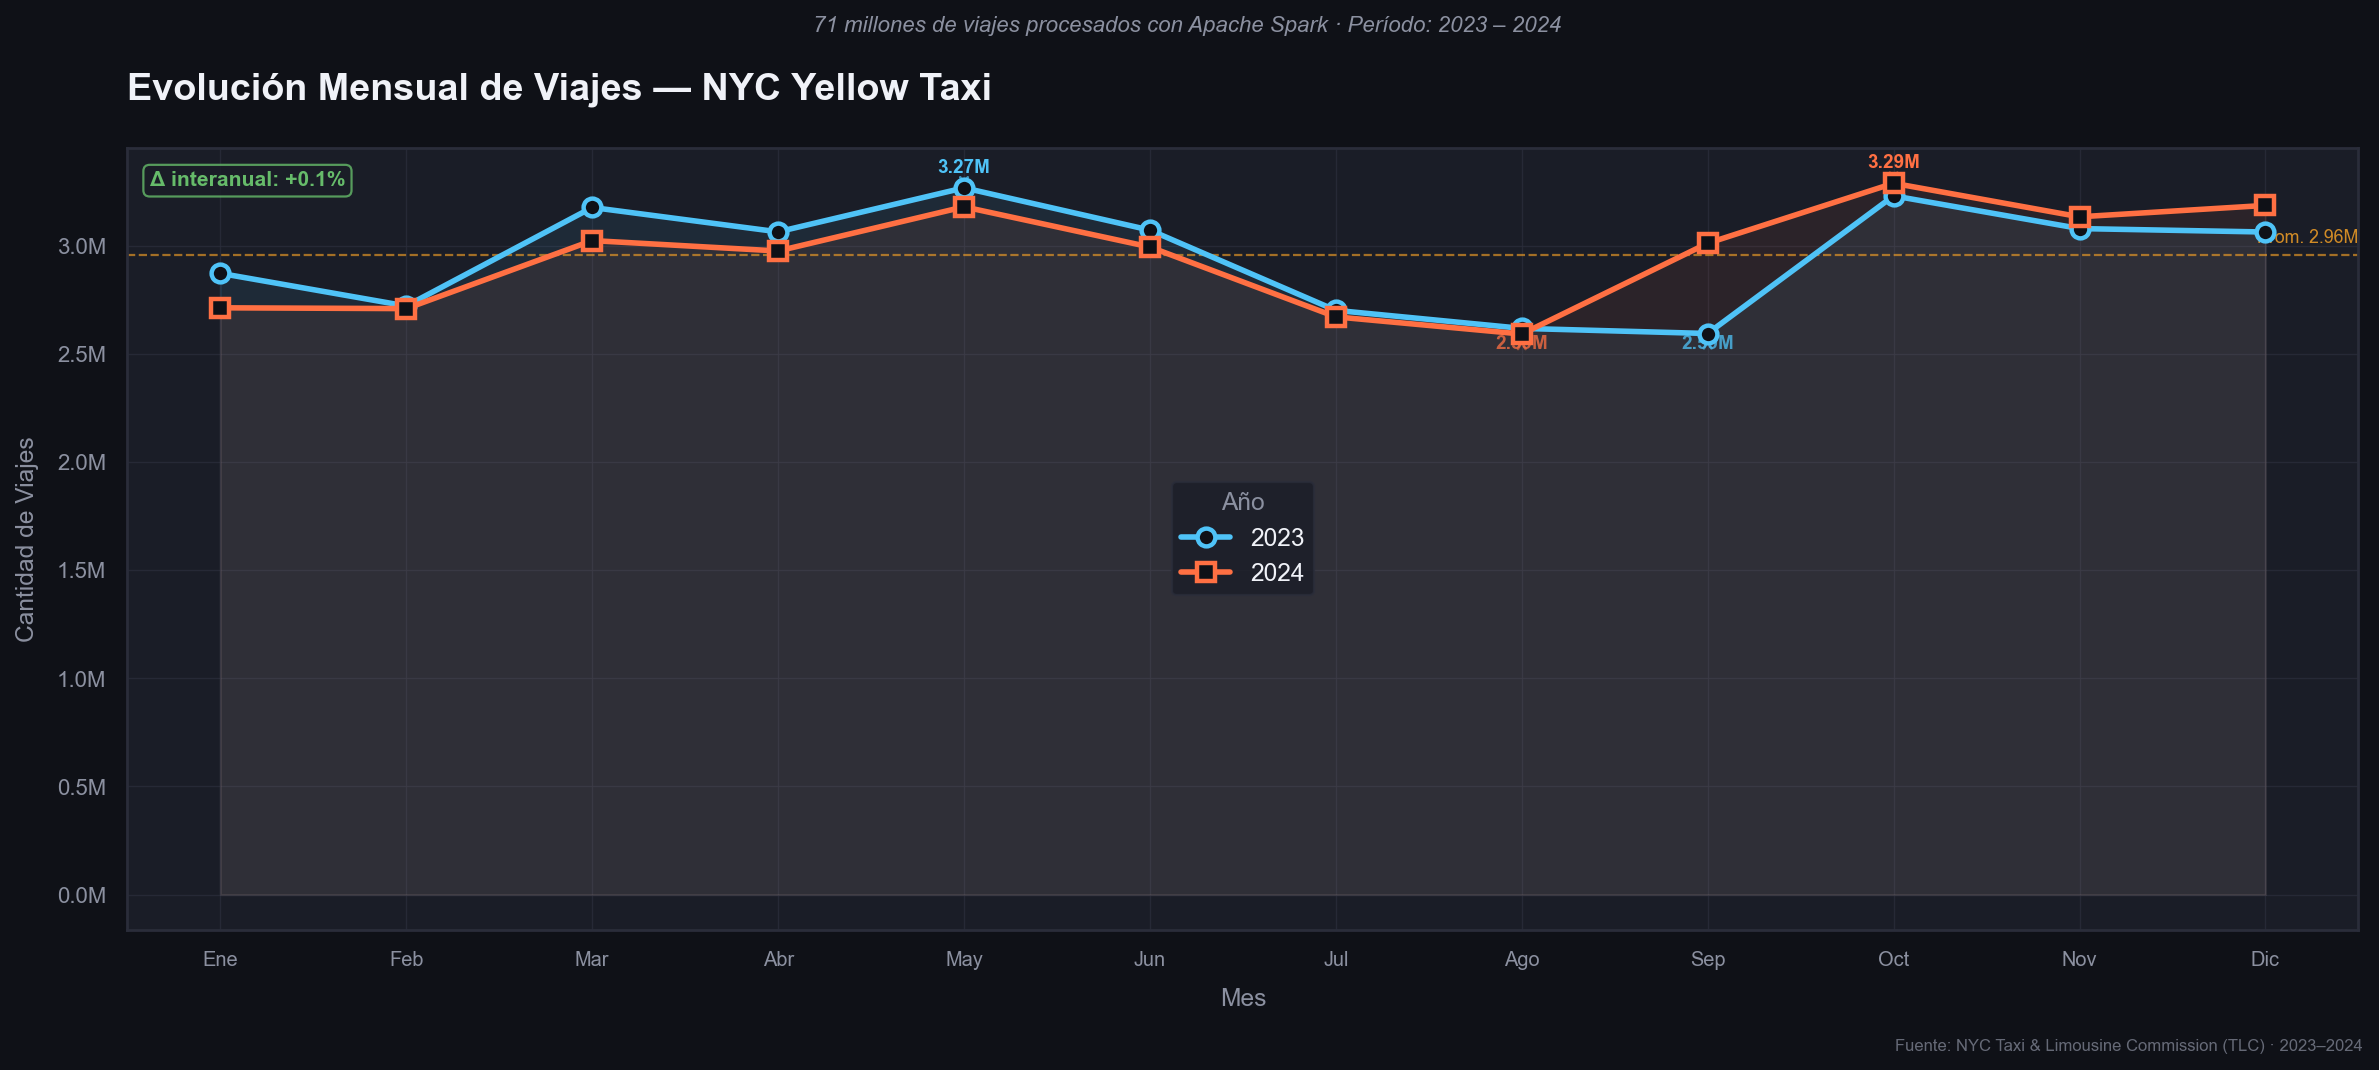

In [43]:
viajes_mes = (
    df_clean
    .groupBy('pickup_month')
    .agg(F.count('*').alias('cantidad_viajes'))
    .orderBy('pickup_month')
    .toPandas()
)
viajes_mes['anio']    = viajes_mes['pickup_month'].str[:4]
viajes_mes['mes_num'] = viajes_mes['pickup_month'].str[5:7].astype(int) - 1  # 0-indexed

anios_presentes = sorted(viajes_mes['anio'].unique())
assert all(a in ['2023', '2024'] for a in anios_presentes), \
    f'Años inesperados: {anios_presentes}'

MESES_LABELS = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
# Estilo por año: (color, marcador). Una sola fuente de verdad.
ANIO_ESTILO   = {'2023': (ACCENT1, 'o'), '2024': (ACCENT2, 's')}
ESTILO_DEFECTO = (ACCENT4, 'D')

fig, ax = plt.subplots(figsize=(15, 7))
apply_dark_style(fig, [ax])

y_global_range = viajes_mes['cantidad_viajes'].max() - viajes_mes['cantidad_viajes'].min()

for anio, grupo in viajes_mes.groupby('anio'):
    grupo = grupo.sort_values('mes_num')
    xs    = grupo['mes_num'].values
    ys    = grupo['cantidad_viajes'].values
    color, marker = ANIO_ESTILO.get(anio, ESTILO_DEFECTO)

    ax.fill_between(xs, ys, alpha=0.08, color=color)
    ax.plot(xs, ys, color=color, lw=2.5,
            marker=marker, markersize=8,
            markerfacecolor=DARK_BG, markeredgewidth=2,
            markeredgecolor=color, label=anio, zorder=5)

    # Anotación del pico (máximo)
    idx_max = ys.argmax()
    ax.annotate(
        f'{ys[idx_max]/1e6:.2f}M',
        xy=(xs[idx_max], ys[idx_max]),
        xytext=(xs[idx_max], ys[idx_max] + y_global_range * 0.10),
        ha='center', fontsize=8.5, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2, alpha=0.7),
    )

    # Anotación del valle (mínimo)
    idx_min = ys.argmin()
    ax.annotate(
        f'{ys[idx_min]/1e6:.2f}M',
        xy=(xs[idx_min], ys[idx_min]),
        xytext=(xs[idx_min], ys[idx_min] - y_global_range * 0.10),
        ha='center', fontsize=8.5, color=color, fontweight='bold', alpha=0.75,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2, alpha=0.5),
    )

ax.set_xticks(range(12))
ax.set_xticklabels(MESES_LABELS, fontsize=9, color=TEXT_SUB)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
prom = viajes_mes['cantidad_viajes'].mean()
ax.axhline(prom, color=ACCENT5, lw=1, linestyle='--', alpha=0.6)
ax.text(11.5, prom * 1.02, f'Prom. {prom/1e6:.2f}M',
        ha='right', fontsize=8, color=ACCENT5, alpha=0.8)

# Indicador de variación interanual
if len(anios_presentes) == 2:
    total_2023 = viajes_mes.loc[viajes_mes['anio'] == '2023', 'cantidad_viajes'].sum()
    total_2024 = viajes_mes.loc[viajes_mes['anio'] == '2024', 'cantidad_viajes'].sum()
    yoy = (total_2024 - total_2023) / total_2023 * 100
    sign = '+' if yoy >= 0 else ''
    badge_color = ACCENT3 if yoy >= 0 else ACCENT2
    ax.text(0.01, 0.97, f'Δ interanual: {sign}{yoy:.1f}%',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=9.5, color=badge_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CARD_BG,
                      edgecolor=badge_color, alpha=0.8))

total_viajes = viajes_mes['cantidad_viajes'].sum()
ax.set_title('Evolución Mensual de Viajes — NYC Yellow Taxi',
             fontsize=17, fontweight='bold', color=TEXT_MAIN, pad=22, loc='left')
add_subtitle(fig, f'{total_viajes/1e6:.0f} millones de viajes procesados con Apache Spark · '
                  f'Período: {anios_presentes[0]} – {anios_presentes[-1]}')
ax.set_xlabel('Mes', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de Viajes', fontsize=11, labelpad=8)
leg = ax.legend(title='Año', fontsize=11, title_fontsize=11,
                facecolor=CARD_BG, edgecolor=GRID_COLOR, labelcolor=TEXT_MAIN)
leg.get_title().set_color(TEXT_SUB)
ax.set_xlim(-0.5, 11.5)
add_source(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig(OUTPUT_DIR / 'visualizacion_1_evolucion_mensual.png', facecolor=DARK_BG)
plt.show()


**Interpretación:**
La gráfica permite comparar la evolución mensual de la demanda entre 2023 y 2024.
En términos generales, los meses de primavera (marzo–mayo) y otoño tienden a registrar mayor actividad,
mientras que los meses de invierno presentan liguas caídas. Las diferencias entre años pueden estar
relacionadas con recuperación post-pandemia, cambios en la competencia con plataformas TNC
(transporte de red) o variaciones en el turismo y la movilidad laboral de Nueva York.


## 9. Visualización 2: Medios de Pago Más Utilizados

**Pregunta analítica:** ¿Cuáles son los medios de pago preferidos por los pasajeros de taxis amarillos?

Entender los hábitos de pago es relevante tanto para la planificación operativa de las flotas como para detectar el nivel de adopción de pagos digitales frente al efectivo.


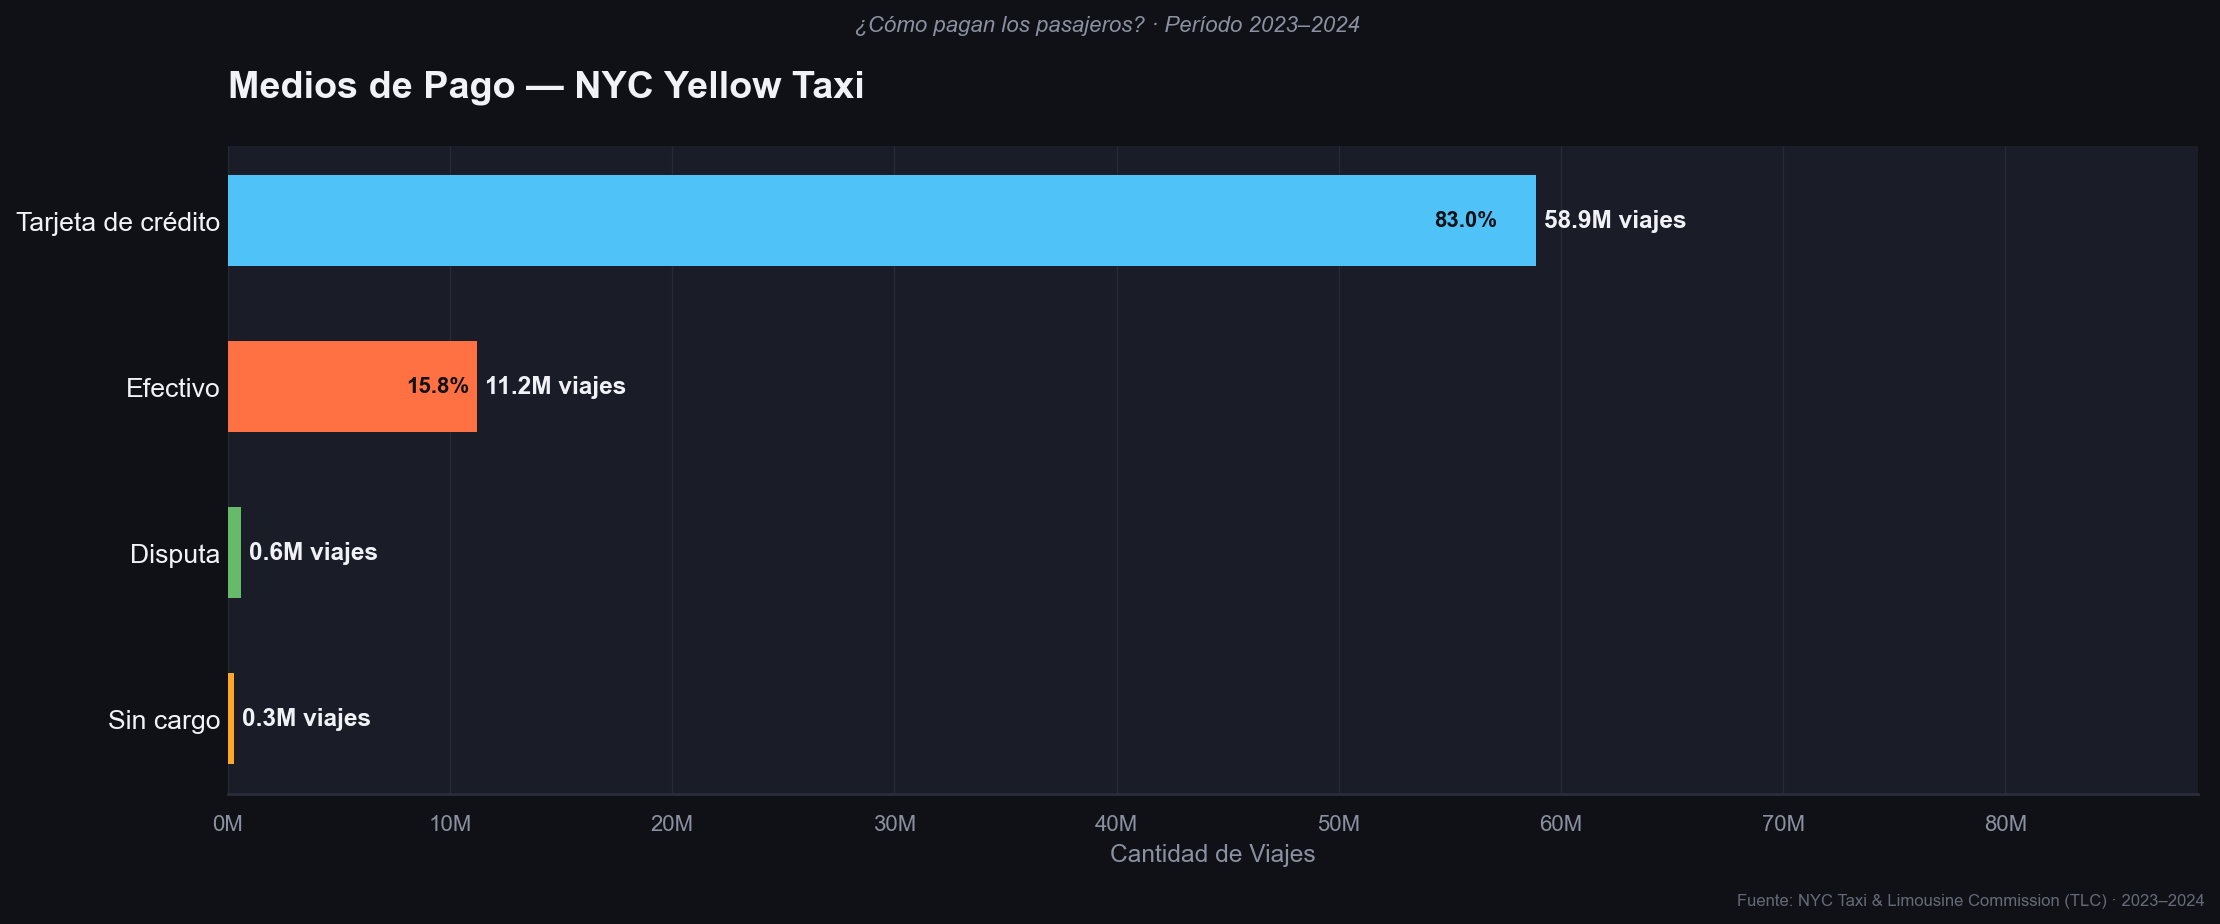

In [44]:
# ── Configuración de medios de pago ──────────────────────────────────────
# (label, color) por código de payment_type → una sola fuente de verdad,
# imposible que etiqueta y color se desincronicen.
PAYMENT_CONFIG = {
    1: ('Tarjeta de crédito', ACCENT1),
    2: ('Efectivo',           ACCENT2),
    3: ('Sin cargo',          ACCENT5),
    4: ('Disputa',            ACCENT3),
    5: ('Desconocido',        ACCENT4),
    6: ('Viaje anulado',      TEXT_SUB),
}
DEFAULT_LABEL, DEFAULT_COLOR = 'Otro', TEXT_SUB

# Diccionario de etiquetas derivado (lo reutiliza la Visualización 3)
PAYMENT_LABELS = {code: label for code, (label, _) in PAYMENT_CONFIG.items()}

# ── Agregación en Spark ───────────────────────────────────────────────────
pagos = (
    df_clean
    .groupBy('payment_type')
    .agg(F.count('*').alias('cantidad_viajes'))
    .toPandas()
)

# Etiqueta, color y porcentaje derivados desde el código (vectorizado)
pagos['medio_pago'] = pagos['payment_type'].map(
    lambda k: PAYMENT_CONFIG.get(k, (DEFAULT_LABEL, DEFAULT_COLOR))[0]
)
pagos['color'] = pagos['payment_type'].map(
    lambda k: PAYMENT_CONFIG.get(k, (DEFAULT_LABEL, DEFAULT_COLOR))[1]
)

total = pagos['cantidad_viajes'].sum()
pagos['pct'] = pagos['cantidad_viajes'] / total * 100
pagos = pagos.sort_values('cantidad_viajes')          # ascendente para barh

# ── Gráfico ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
apply_dark_style(fig, [ax])

bars = ax.barh(pagos['medio_pago'], pagos['cantidad_viajes'],
               color=pagos['color'], height=0.55, edgecolor='none')

PCT_INNER_THRESHOLD = 0.03   # solo mostrar % dentro de barras suficientemente largas

for bar, row in zip(bars, pagos.itertuples()):
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    # Etiqueta de volumen (fuera de la barra)
    ax.text(w + total * 0.005, y, f'{w / 1e6:.1f}M viajes',
            va='center', ha='left', fontsize=11,
            color=TEXT_MAIN, fontweight='bold')

    # Porcentaje (dentro de la barra) si hay espacio
    if w > total * PCT_INNER_THRESHOLD:
        ax.text(w * 0.97, y, f'{row.pct:.1f}%',
                va='center', ha='right', fontsize=10,
                color=DARK_BG, fontweight='bold')

ax.set_xlim(0, total * 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.0f}M'))
ax.set_title('Medios de Pago — NYC Yellow Taxi',
             fontsize=17, fontweight='bold', color=TEXT_MAIN, pad=22, loc='left')
add_subtitle(fig, '¿Cómo pagan los pasajeros? · Período 2023–2024')
ax.set_xlabel('Cantidad de Viajes', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12, labelcolor=TEXT_MAIN, length=0)
ax.grid(axis='x', color=GRID_COLOR, linewidth=0.6)
ax.grid(axis='y', visible=False)
for spine in ('top', 'right', 'left'):
    ax.spines[spine].set_visible(False)
ax.set_axisbelow(True)
add_source(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig(OUTPUT_DIR / 'visualizacion_2_medios_pago.png', facecolor=DARK_BG)
plt.show()


**Interpretación:**
La tarjeta de crédito domina como el medio de pago predominante, reflejando una tendencia clara hacia la digitalización de los pagos en el transporte urbano.
El efectivo ocupa el segundo lugar, aunque con una participación considerablemente menor.
Los medios restantes (sin cargo, disputa, anulado) representan fracciones muy pequeñas del total,
lo que indica que la mayoría de las transacciones se completan sin inconvenientes.


## 10. Visualización 3: Relación Distancia — Valor Total Pagado

**Pregunta analítica:** ¿En qué medida la distancia del viaje explica el valor total cobrado?

Se toma una muestra representativa directamente en Spark para evitar convertir todo el dataset a Pandas.
Los valores se acotan a rangos razonables para reducir la influencia de registros atípicos.


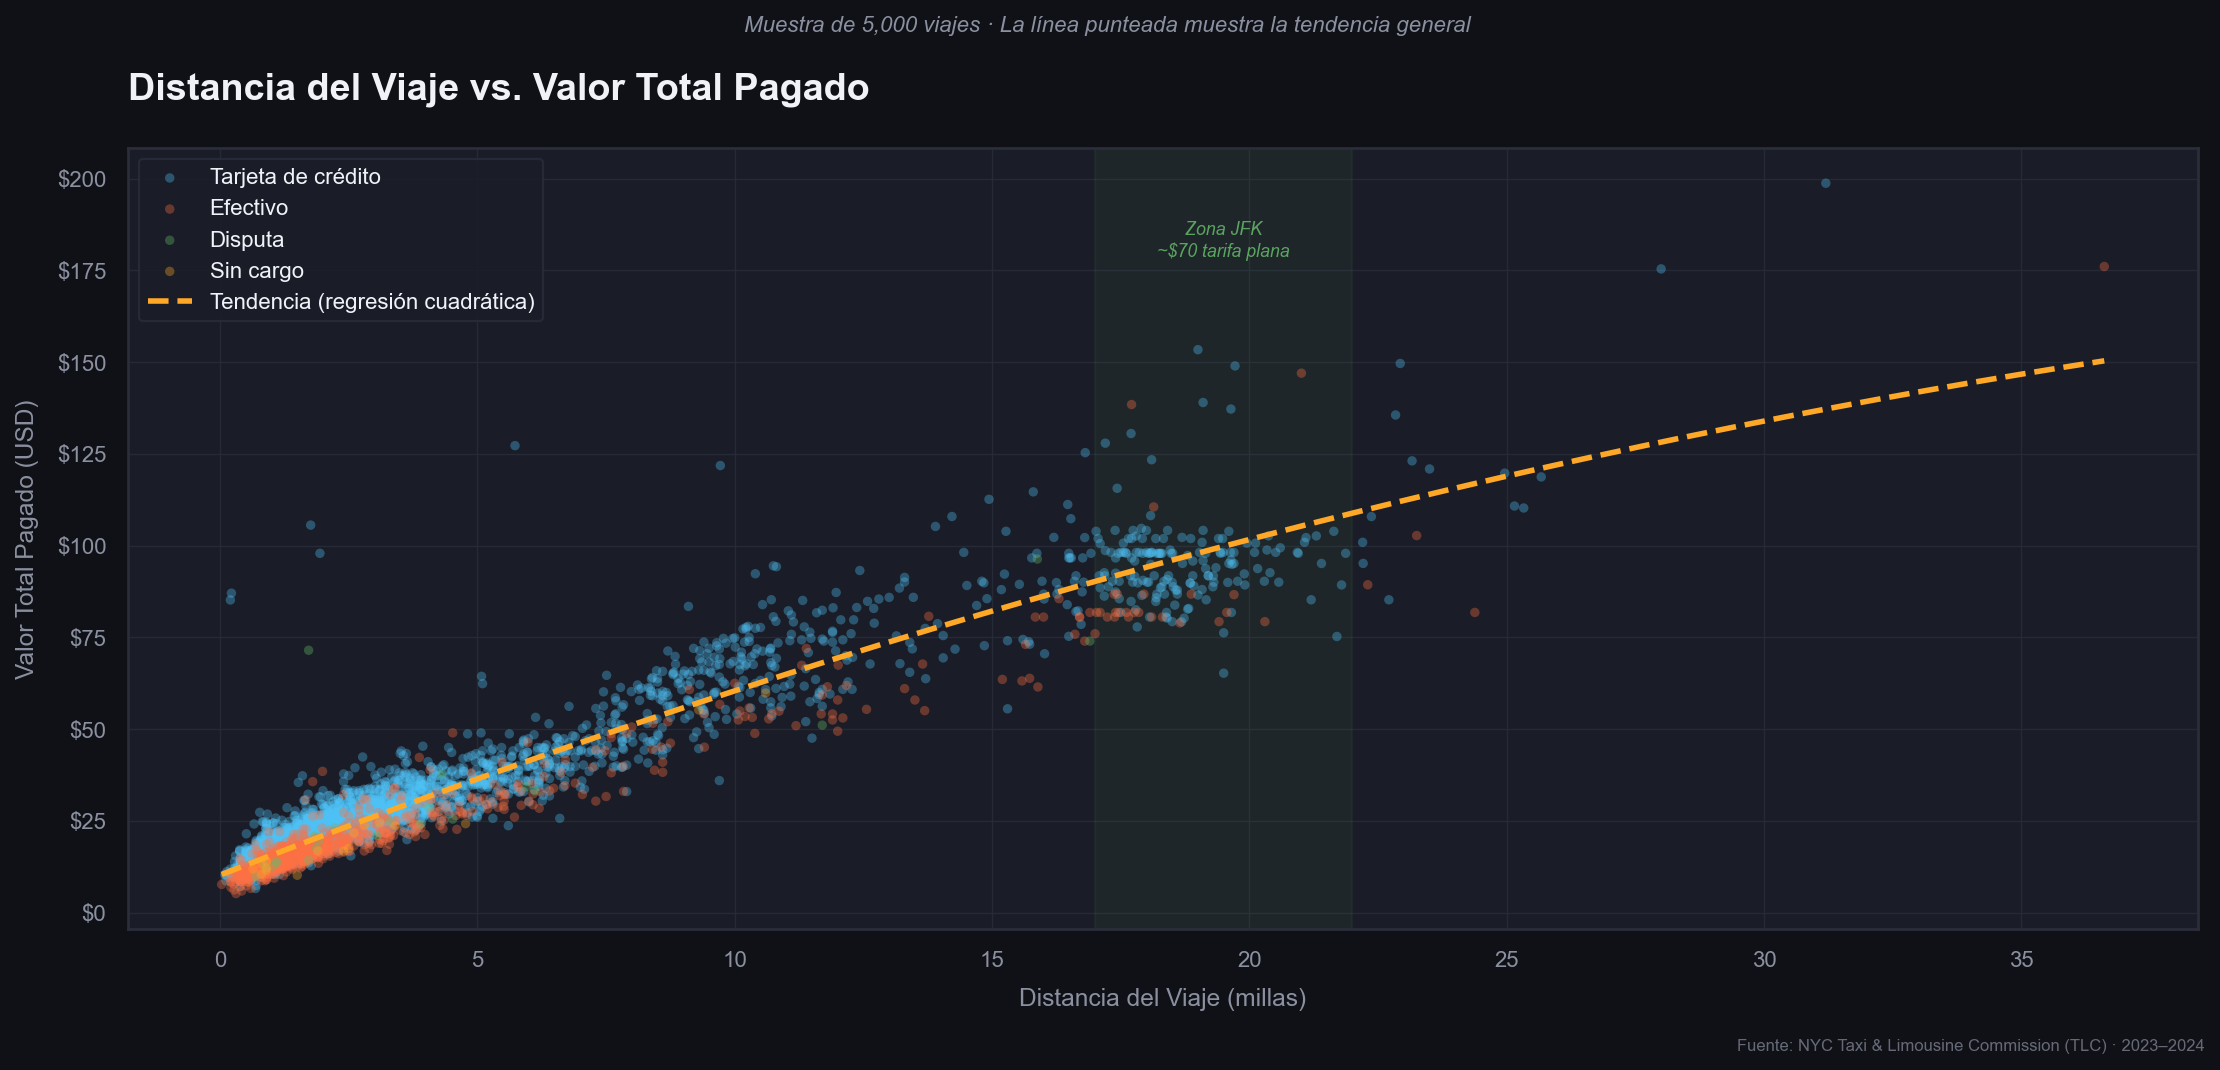

In [45]:
import numpy as np

# ── Muestra para la dispersión (se toma en Spark, no se baja todo a pandas) ─
MAX_DIST_MI   = 40     # acotar millas y monto reduce el peso de atípicos
MAX_TOTAL_USD = 200
N_MUESTRA     = 5000

scatter_df = (
    df_clean
    .select('trip_distance', 'total_amount', 'payment_type')
    .filter((F.col('trip_distance') <= MAX_DIST_MI) & (F.col('total_amount') <= MAX_TOTAL_USD))
    .sample(withReplacement=False, fraction=0.001, seed=42)
    .limit(N_MUESTRA)
    .toPandas()
)

# Etiqueta y color reutilizando PAYMENT_CONFIG → colores coherentes con la
# Visualización 2 en todo el notebook (sin diccionario de colores duplicado).
LABEL_COLORS = {label: color for label, color in PAYMENT_CONFIG.values()}
scatter_df['medio_pago'] = scatter_df['payment_type'].map(
    lambda k: PAYMENT_CONFIG.get(k, (DEFAULT_LABEL, DEFAULT_COLOR))[0]
)

fig, ax = plt.subplots(figsize=(14, 7))
apply_dark_style(fig, [ax])

# Una serie por medio de pago, los más frecuentes dibujados al frente
for medio in scatter_df['medio_pago'].value_counts().index:
    sub = scatter_df[scatter_df['medio_pago'] == medio]
    ax.scatter(sub['trip_distance'], sub['total_amount'],
               c=LABEL_COLORS.get(medio, DEFAULT_COLOR), alpha=0.35, s=18,
               label=medio, zorder=3, edgecolors='none')

# Línea de tendencia (regresión cuadrática) sobre el rango real de los datos
z = np.polyfit(scatter_df['trip_distance'], scatter_df['total_amount'], 2)
p = np.poly1d(z)
xs_line = np.linspace(scatter_df['trip_distance'].min(),
                      scatter_df['trip_distance'].max(), 200)
ax.plot(xs_line, p(xs_line), color=ACCENT5, lw=2.5, linestyle='--',
        label='Tendencia (regresión cuadrática)', zorder=6)

# Zona JFK
ax.axvspan(17, 22, alpha=0.06, color=ACCENT3, zorder=1)
ax.text(19.5, scatter_df['total_amount'].max() * 0.9,
        'Zona JFK\n~$70 tarifa plana',
        ha='center', fontsize=8, color=ACCENT3, alpha=0.85, style='italic')

ax.set_title('Distancia del Viaje vs. Valor Total Pagado',
             fontsize=17, fontweight='bold', color=TEXT_MAIN, pad=22, loc='left')
add_subtitle(fig, f'Muestra de {len(scatter_df):,} viajes · La línea punteada muestra la tendencia general')
ax.set_xlabel('Distancia del Viaje (millas)', fontsize=11, labelpad=8)
ax.set_ylabel('Valor Total Pagado (USD)', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
leg = ax.legend(fontsize=10, facecolor=CARD_BG,
                edgecolor=GRID_COLOR, labelcolor=TEXT_MAIN)
add_source(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig(OUTPUT_DIR / 'visualizacion_3_distancia_total.png', facecolor=DARK_BG)
plt.show()


**Interpretación:**
La gráfica confirma una **correlación positiva** entre la distancia recorrida y el valor total pagado:
a mayor distancia, mayor costo del viaje. Sin embargo, existe una dispersión considerable, especialmente
en la franja de 0–10 millas, lo que refleja la influencia de variables adicionales como peajes,
propinas, la tarifa de aeropuerto (`airport_fee`) y el cargo por congestión (`congestion_surcharge`).
Los viajes pagados con tarjeta de crédito tienden a mostrar mayor variabilidad en el valor total,
posiblemente porque este método facilita el registro de propinas más altas.


## 11. Visualización 4: Mapa de Calor — Demanda por Día y Hora

**Pregunta analítica:** ¿En qué combinaciones de día de la semana y hora del día se concentra la mayor demanda de taxis?

Esta visualización es fundamental para la planificación operativa: permite identificar picos de demanda y períodos de baja actividad.


Exception in thread Thread-3:
Traceback (most recent call last):
  File "c:\Users\JHON VARGAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\py4j\clientserver.py", line 50, in run
    task = self.deque.pop()
           ^^^^^^^^^^^^^^^^
IndexError: pop from an empty deque

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\JHON VARGAS\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\JHON VARGAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\py4j\clientserver.py", line 58, in run
    time.sleep(DEFAULT_WORKER_SLEEP_TIME)
OSError: [WinError 1450] Recursos insuficientes en el sistema para completar el servicio solicitado


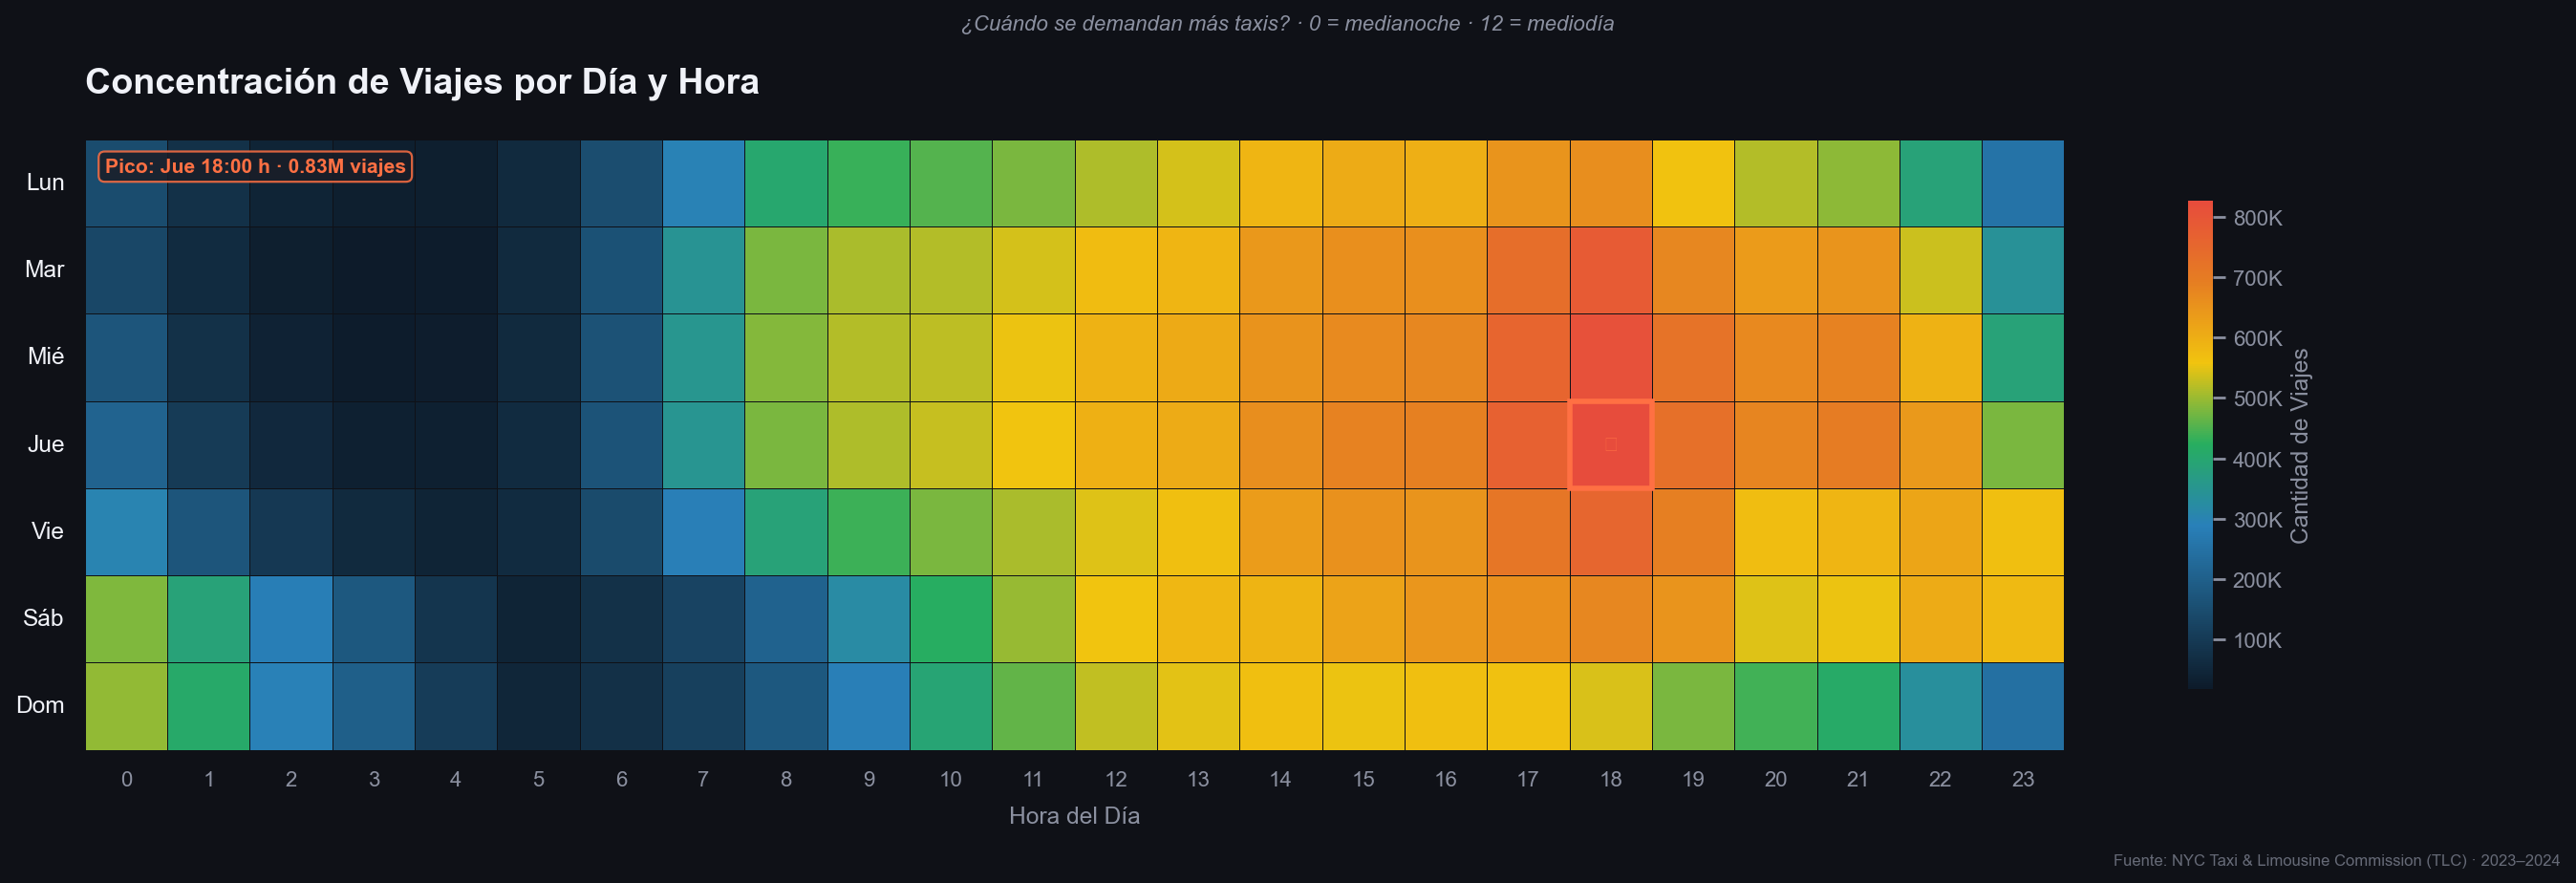

In [46]:
import numpy as np

heatmap_df = (
    df_clean
    .groupBy('pickup_day', 'pickup_hour')
    .agg(F.count('*').alias('cantidad_viajes'))
    .toPandas()
)

DAY_ORDER_EN = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
DAY_ES = {'Mon': 'Lun', 'Tue': 'Mar', 'Wed': 'Mié', 'Thu': 'Jue',
          'Fri': 'Vie', 'Sat': 'Sáb', 'Sun': 'Dom'}

heatmap_df['pickup_day'] = pd.Categorical(
    heatmap_df['pickup_day'], categories=DAY_ORDER_EN, ordered=True)

# Reindexar a las 24 horas garantiza que ninguna columna falte aunque
# alguna hora no tenga viajes en la muestra.
pivot = (
    heatmap_df
    .pivot_table(index='pickup_day', columns='pickup_hour',
                 values='cantidad_viajes', aggfunc='sum', observed=False)
    .reindex(columns=range(24))
    .fillna(0)
)
pivot.index = [DAY_ES[d] for d in pivot.index]

cmap_taxi = LinearSegmentedColormap.from_list(
    'taxi', ['#0d1b2a', '#1b4f72', '#2980b9', '#27ae60',
             '#f1c40f', '#e67e22', '#e74c3c'])

fig, ax = plt.subplots(figsize=(17, 6))
apply_dark_style(fig, [ax])

sns.heatmap(pivot, cmap=cmap_taxi, ax=ax,
            linewidths=0.4, linecolor=DARK_BG,
            annot=False,
            cbar_kws={'label': 'Cantidad de Viajes', 'shrink': 0.8})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT_SUB)
cbar.ax.tick_params(colors=TEXT_SUB)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Marcar y etiquetar el pico máximo (día + hora)
peak_row, peak_col = np.unravel_index(pivot.values.argmax(), pivot.shape)
peak_val  = pivot.values[peak_row, peak_col]
peak_dia  = pivot.index[peak_row]
peak_hora = pivot.columns[peak_col]

ax.add_patch(plt.Rectangle(
    (peak_col, peak_row), 1, 1,
    fill=False, edgecolor=ACCENT2, lw=2.5, zorder=5))
ax.text(peak_col + 0.5, peak_row + 0.5, '★',
        ha='center', va='center', fontsize=10,
        color=ACCENT2, fontweight='bold', zorder=6)

ax.text(0.01, 0.97, f'Pico: {peak_dia} {peak_hora:02d}:00 h · {peak_val/1e6:.2f}M viajes',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9.5, color=ACCENT2, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=CARD_BG,
                  edgecolor=ACCENT2, alpha=0.85))

ax.set_title('Concentración de Viajes por Día y Hora',
             fontsize=17, fontweight='bold', color=TEXT_MAIN, pad=22, loc='left')
add_subtitle(fig, '¿Cuándo se demandan más taxis? · 0 = medianoche · 12 = mediodía')
ax.set_xlabel('Hora del Día', fontsize=11, labelpad=8)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0, labelsize=11, labelcolor=TEXT_MAIN)
ax.tick_params(axis='x', labelsize=10, labelcolor=TEXT_SUB)
add_source(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig(OUTPUT_DIR / 'visualizacion_4_calor_dia_hora.png', facecolor=DARK_BG)
plt.show()


**Interpretación:**
El mapa de calor revela patrones claros de movilidad urbana en Nueva York:

- **Pico vespertino–nocturno (17:00–23:00):** los viernes y sábados concentran la mayor demanda, asociada a salidas nocturnas y vida social.
- **Horas pico laborales (7:00–9:00 y 17:00–19:00):** de lunes a viernes se observa el patrón típico de desplazamientos al trabajo (commuting).
- **Valle nocturno (2:00–5:00):** todos los días registran actividad mínima, aunque los domingos muestran mayor actividad nocturna tardía respecto a días entre semana.
- **Fines de semana:** la demanda se distribuye de forma más uniforme a lo largo del día, sin los picos bimoidales característicos de los días laborales.


## 12. Visualización 5: Distribución del Valor Total Pagado

**Pregunta analítica:** ¿Cómo se distribuyen los montos pagados por los usuarios? ¿Cuáles son los rangos de pago más frecuentes?

Se generan intervalos de 5 USD directamente en Spark para evitar transferir millones de filas a Pandas, trasladando únicamente los conteos agregados.


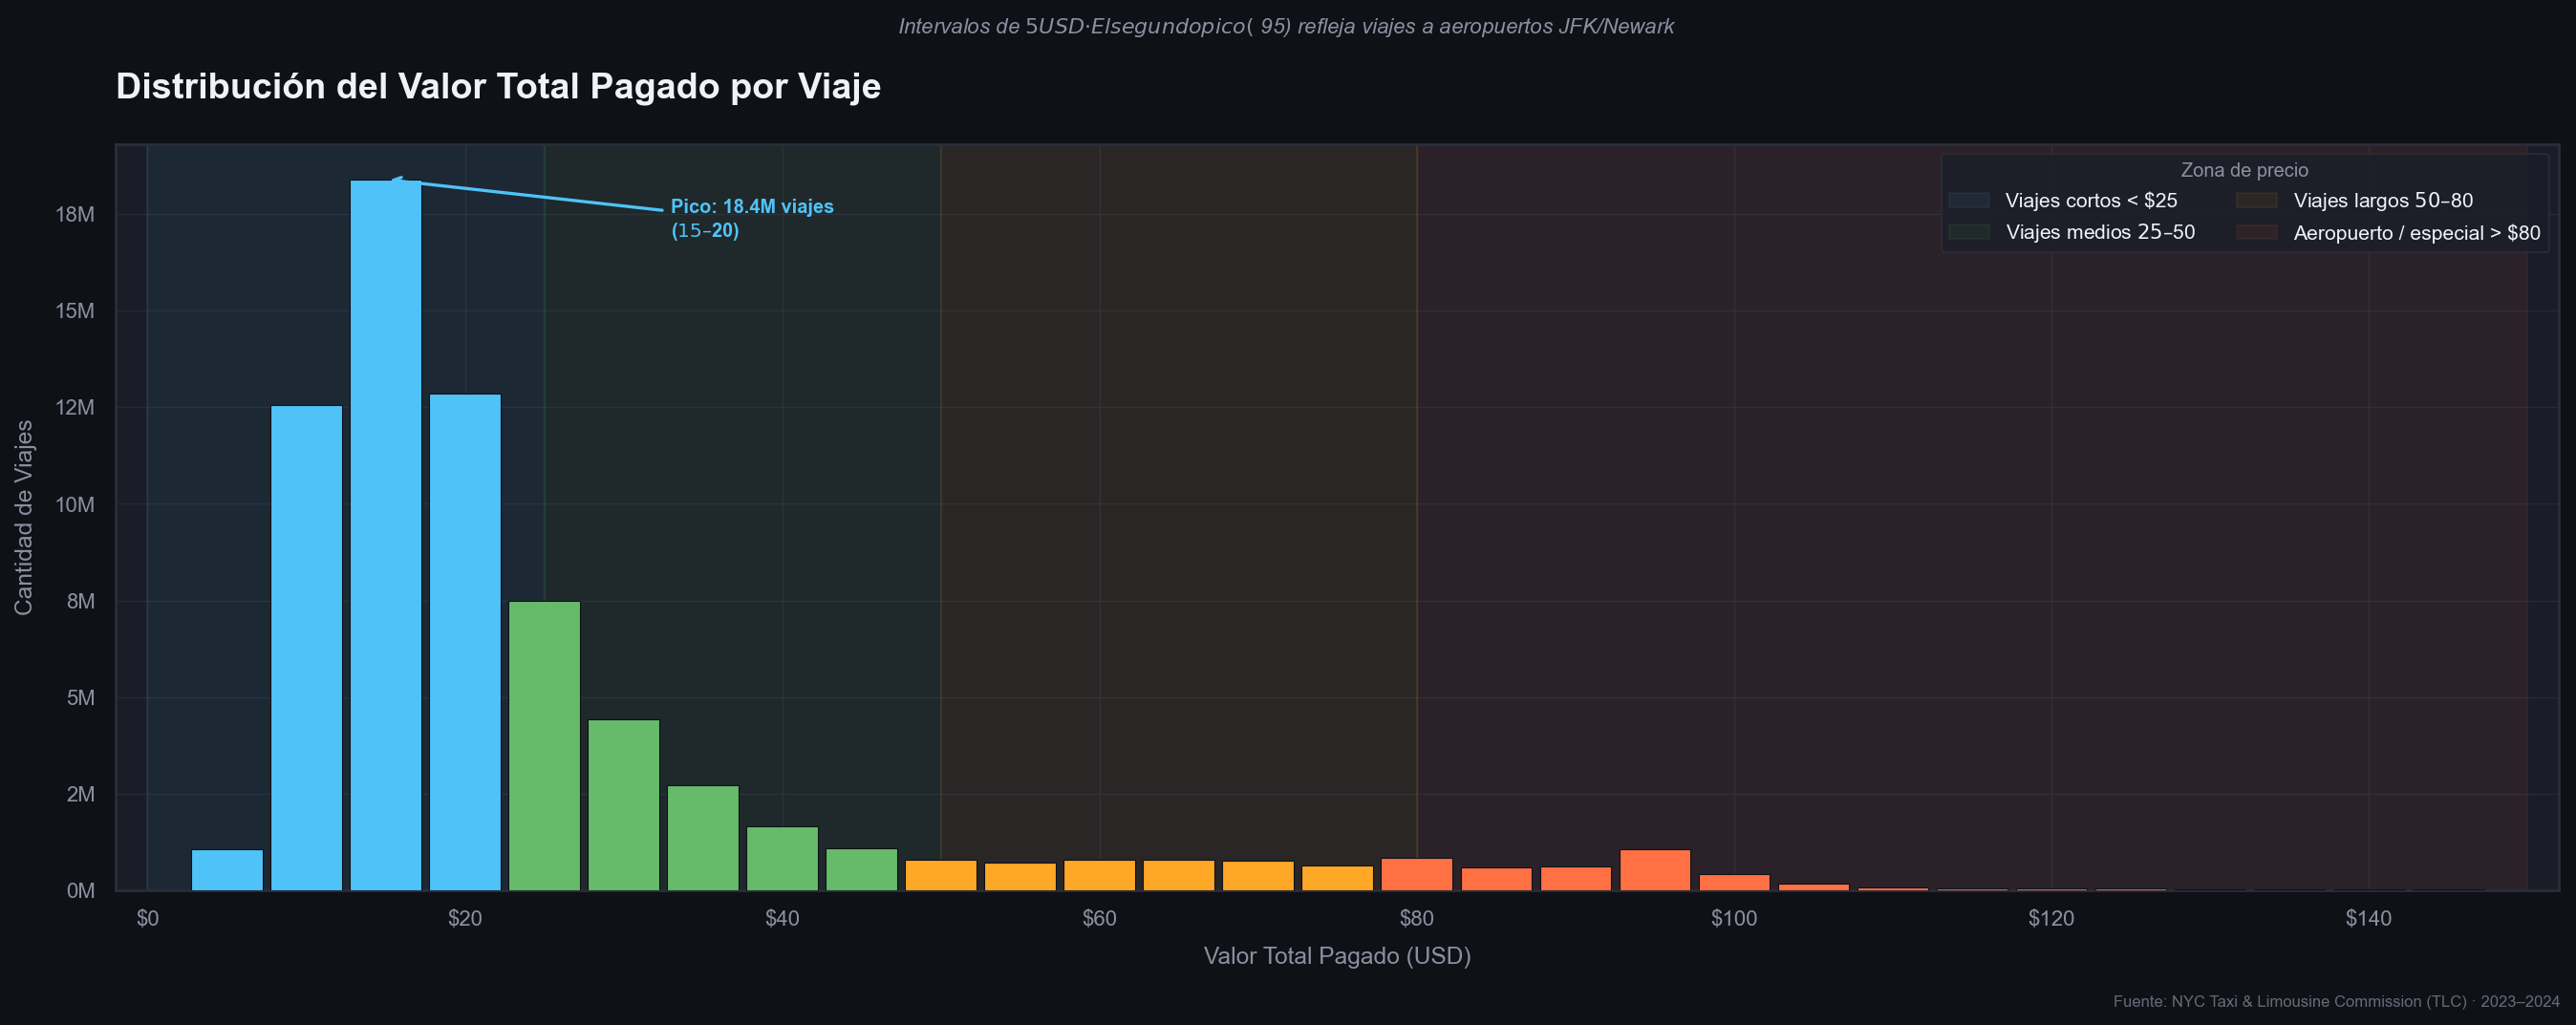

In [13]:
INTERVALO_USD = 5
MAX_TOTAL_USD = 150

# Zonas de precio: (límite_superior, color, etiqueta). Única fuente de verdad
# que alimenta tanto el color de las barras como las bandas de fondo.
ZONAS_PRECIO = [
    (25,            ACCENT1, 'Viajes cortos < $25'),
    (50,            ACCENT3, 'Viajes medios $25–$50'),
    (80,            ACCENT5, 'Viajes largos $50–$80'),
    (MAX_TOTAL_USD, ACCENT2, 'Aeropuerto / especial > $80'),
]

def zona_color(rango):
    for limite, color, _ in ZONAS_PRECIO:
        if rango < limite:
            return color
    return ZONAS_PRECIO[-1][1]

distribucion = (
    df_clean
    .filter((F.col('total_amount') > 0) & (F.col('total_amount') <= MAX_TOTAL_USD))
    .withColumn(
        'rango_total',
        (F.floor(F.col('total_amount') / INTERVALO_USD) * INTERVALO_USD).cast('int')
    )
    .groupBy('rango_total')
    .agg(F.count('*').alias('cantidad_viajes'))
    .orderBy('rango_total')
    .toPandas()
)
distribucion['color'] = distribucion['rango_total'].apply(zona_color)

fig, ax = plt.subplots(figsize=(17, 7))
apply_dark_style(fig, [ax])

ax.bar(distribucion['rango_total'], distribucion['cantidad_viajes'],
       width=INTERVALO_USD * 0.9, color=distribucion['color'],
       edgecolor=DARK_BG, linewidth=0.5, zorder=3)

# Bandas de fondo por zona, derivadas de ZONAS_PRECIO
x0 = 0
for limite, color, label in ZONAS_PRECIO:
    ax.axvspan(x0, limite, color=color, alpha=0.07, zorder=1, label=label)
    x0 = limite

# Anotación del pico principal
idx_peak = distribucion['cantidad_viajes'].idxmax()
peak_x   = distribucion.loc[idx_peak, 'rango_total']
peak_y   = distribucion.loc[idx_peak, 'cantidad_viajes']
ax.annotate(
    f'Pico: {peak_y/1e6:.1f}M viajes\n(${peak_x}–${peak_x + INTERVALO_USD})',
    xy=(peak_x, peak_y),
    xytext=(peak_x + 18, peak_y * 0.92),
    arrowprops=dict(arrowstyle='->', color=ACCENT1, lw=1.5),
    fontsize=9, color=ACCENT1, fontweight='bold'
)

ax.set_title('Distribución del Valor Total Pagado por Viaje',
             fontsize=17, fontweight='bold', color=TEXT_MAIN, pad=22, loc='left')
add_subtitle(fig, 'Intervalos de $5 USD · El segundo pico (~$95) refleja viajes a aeropuertos JFK/Newark')
ax.set_xlabel('Valor Total Pagado (USD)', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de Viajes', fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.set_xlim(-2, MAX_TOTAL_USD + 2)
ax.set_axisbelow(True)
leg = ax.legend(fontsize=9.5, facecolor=CARD_BG, edgecolor=GRID_COLOR,
                labelcolor=TEXT_MAIN, loc='upper right', ncol=2,
                title='Zona de precio', title_fontsize=9)
leg.get_title().set_color(TEXT_SUB)
add_source(fig)
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig(OUTPUT_DIR / 'visualizacion_5_distribucion_total.png', facecolor=DARK_BG)
plt.show()


**Interpretación:**
La distribución muestra una **asimetría positiva** (sesgo a la derecha): la mayoría de los viajes se pagan en el rango de **$5 a $25 USD**, correspondiente a trayectos cortos o medianos dentro de Manhattan y los boroughs adyacentes.
La frecuencia disminuye progresivamente conforme aumenta el valor, con una pequeña elevación alrededor de $50–60 USD que podría corresponder a las tarifas fijas hacia los aeropuertos (JFK: tarifa plana de $70 + propina, Newark: tarifa estimada ~$50–80).
Los valores muy altos (> $100 USD) representan una minoría de viajes de larga distancia o con múltiples cargos adicionales.


## 13. Conclusiones

A partir del análisis realizado sobre más de **79 millones de viajes** de taxis amarillos de Nueva York durante 2023 y 2024, se concluye que:

### Principales hallazgos del análisis

1. **La demanda presenta estacionalidad** con picos en primavera y otoño, y mínimos en los meses de invierno, lo que puede relacionarse con el clima, el turismo y los patrones laborales de la ciudad.

2. **La tarjeta de crédito domina como medio de pago**, representando la mayoría de las transacciones y confirmando la tendencia hacia la digitalización del transporte urbano.

3. **Existe una correlación positiva clara** entre la distancia del viaje y el valor total pagado, aunque con alta dispersión producida por cargos adicionales como peajes, propinas y la tarifa de aeropuerto.

4. **Los picos de demanda ocurren en las tardes–noches**, especialmente los viernes y sábados, con el patrón clásico de doble pico laboral de lunes a viernes. Esta información es valiosa para la asignación óptima de flotas.

5. **La distribución de valores pagados** confirma que la mayoría de los viajes son cortos (< $25 USD), con una larga cola de viajes especiales o de mayor distancia.

### Aprendizajes sobre el uso de Spark

- **Apache Spark demostró ser la herramienta adecuada** para procesar un dataset superior a 1 GB sin necesidad de cargar todos los datos en memoria: las agregaciones se ejecutaron de forma distribuida y solo los resultados reducidos se transfirieron a Pandas para graficar.
- El patrón de trabajo eficiente fue **agregar/filtrar en Spark y graficar en Pandas/Matplotlib**, evitando traer millones de filas al driver.
- La **evaluación perezosa (lazy)** de Spark permite encadenar transformaciones y ejecutarlas solo al invocar acciones como `count()` o `collect()`, optimizando el plan de ejecución.
- El formato **Parquet** (columnar y comprimido) acelera notablemente la lectura frente a CSV y reduce el volumen en disco.
- La **normalización de esquemas** entre archivos de distintos meses fue clave para poder unirlos sin errores de tipos.

### Limitaciones encontradas

- El análisis no incorporó variables externas (clima, eventos masivos, tráfico) que podrían explicar variaciones específicas en la demanda.
- No se realizó comparación con otros modos de transporte (Uber/Lyft, metro, autobús).
- La muestra utilizada en la Visualización 3 es representativa pero no exhaustiva del universo total de viajes.
- El procesamiento depende de los recursos (RAM/CPU) de la máquina local, lo que puede limitar la cantidad de meses procesables sin un clúster.


## 14. Cierre de la Sesión Spark

Una vez completado el análisis, se cierra la sesión Spark para liberar los recursos del sistema.


In [ ]:
spark.stop()
print('Sesión Spark cerrada correctamente.')
print(f'Gráficas guardadas en: {OUTPUT_DIR}')
